###Assignment: 3D CNNs for Video Classification






###Part 1: C3D Baseline and Temporal Analysis
Background:\
You saw in the demo that C3D trained from scratch on 250 clips completely failed, collapsing to a single predicted class. In this part you will reproduce that result, understand why it happens, and run targeted experiments to probe what the 2D CNN baseline actually learns about time.\
Tasks\
**1a.** **Train C3D and reproduce the demo result**\
The C3D architecture and training code are available from the demo notebook. Train C3D for **20 epochs** on the **UCF101 subset**. Report:

(i) Final train and test accuracy
(ii) Loss and accuracy curves
(iii) Confusion matrix and per-class F1

Keep **learning rate to 1e-4** and report whether this changes the collapse behaviour. Explain your observation in 3-4 sentences.

**1b.** **Learning rate experiment** \
Train C3D three times with learning rates 1e-3, 1e-4, 1e-5. Plot all three train loss curves on the same graph. Answer:

(i) Which learning rate gives the best result?
(ii) What happens at 1e-5 and why?
(iii) What does this tell you about training deep networks from scratch on small datasets?

**1c.** **Temporal blindness experiments**
In the demo, shuffling all 16 frames of a clip gave cosine similarity ≈ 1.0 between original and shuffled for the 2D CNN, proving it is completely blind to temporal order.\
Now run the following three experiments on the 2D CNN and report cosine similarity for each:

Exp 1: Shuffle only the first 8 frames, keep last 8 in original order\
Exp 2: Reverse the entire clip (frame 15 → 0)\
Exp 3: Replace all frames with the middle frame repeated 16 times (completely static clip)

Then repeat all three experiments using your trained C3D model's feature embeddings (add a get_features method similar to the demo).
Present results in the following table:

| Corruption | 2D CNN similarity | C3D similarity |
|------------|------------------|----------------|
| Half shuffle |  |  |
| Reversed |  |  |
| Static (repeated frame) |  |  |

Answer in 4–5 sentences: what do the differences between 2D CNN and C3D similarities tell you about what each model has learned?

In [1]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q torchinfo gdown scikit-learn seaborn matplotlib opencv-python-headless pytorchvideo
!pip install -q av

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 65.7 MB/s eta 0:00:00


In [2]:
import os, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as T
from torchvision.models.video import mvit_v2_s, MViT_V2_S_Weights
from torchinfo import summary

from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score)

warnings.filterwarnings('ignore')


SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4
VRAM     : 15.6 GB


In [3]:
# Download UCF101 subset
!pip install -q huggingface_hub

import tarfile
from pathlib import Path
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(repo_id="aisuko/ucf101-subset",filename="UCF101_subset.tar.gz",repo_type="dataset")
print(f"Downloaded to: {file_path}")

DATA_DIR = Path("./ucf_subset")
with tarfile.open(file_path) as t:
    t.extractall(".")

import shutil
from pathlib import Path

DATA_DIR = Path("./ucf_subset")
DATA_DIR.mkdir(exist_ok=True)

RAW_DIR = Path("./UCF101_subset")

UCF101_subset.tar.gz:   0%|          | 0.00/171M [00:00<?, ?B/s]

Downloaded to: /root/.cache/huggingface/hub/datasets--aisuko--ucf101-subset/snapshots/9b960801da721d25745d23b14cb24ff78398b785/UCF101_subset.tar.gz


In [4]:
RAW_DIR = Path("./UCF101_subset")

CLASS_NAMES = sorted([d.name for d in (RAW_DIR / "train").iterdir() if d.is_dir()])

print(f"{'Class':<25} {'Train':>6} {'Val':>6} {'Test':>6} {'Total':>7}")
print("-" * 50)
for cls in CLASS_NAMES:
    counts = {}
    for split in ["train", "val", "test"]:
        counts[split] = len(list((RAW_DIR / split / cls).glob("*.avi")))
    total = sum(counts.values())
    print(f"  {cls:<23} {counts['train']:>6} {counts['val']:>6} {counts['test']:>6} {total:>7}")

Class                      Train    Val   Test   Total
--------------------------------------------------
  ApplyEyeMakeup              30      3      6      39
  ApplyLipstick               30      3      4      37
  Archery                     30      3      7      40
  BabyCrawling                30      3      9      42
  BalanceBeam                 30      3      4      37
  BandMarching                30      3      9      42
  BaseballPitch               30      3     10      43
  Basketball                  30      3     11      44
  BasketballDunk              30      3      6      39
  BenchPress                  30      3      9      42


In [5]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import numpy as np
from pathlib import Path
import random

class UCFClipDataset(Dataset):
  def __init__(self, root, class_names, n_frames=16, size=112):
    self.root        = Path(root)
    self.class_names = class_names
    self.n_frames    = n_frames
    self.size        = size
    self.label_map   = {c: i for i, c in enumerate(class_names)}

    self.clips = []
    for cls in class_names:
      vids = sorted((self.root / cls).glob("*.avi")) + \
              sorted((self.root / cls).glob("*.mp4"))
      for v in vids:
        self.clips.append((v, self.label_map[cls])) #video path, label id (0,1,....9)

    self.transform = T.Compose([
        T.Resize((size, size), antialias=True), #antialiasing = true leads to smoother frames and more stable features when downsampling
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]), # standard imagenet normalisation
    ])

  def _load_clip(self, path):
    cap    = cv2.VideoCapture(str(path)) #read video file
    total  = max(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), 1) # read total video frames, if 0 frames, then consider total = 1 to avoid division by 0
    indices = np.linspace(0, total - 1, self.n_frames, dtype=int) #suppose total = 100, n_frames = 16, indices=[0,6,12,....]
    frames = []
    for idx in indices:
      cap.set(cv2.CAP_PROP_POS_FRAMES, idx) #move video pointer to frame idx
      ret, frame = cap.read() # read frame, ret=success flag, frame = image array
      if not ret or frame is None:
        frame = np.zeros((self.size, self.size, 3), dtype=np.uint8) #if error in reading frame, replace it by black frame
      else:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) #cv2 reads in BGR format, CNN expects RGB format
        frame = cv2.resize(frame, (self.size, self.size)) # though transform has already been applied still
      frames.append(frame)
    cap.release() #close video file

    # Now all frames are guaranteed (self.size, self.size, 3)
    arr = torch.from_numpy(np.stack(frames)).float() / 255.0  # (T, H, W, C), convert to tensor, normalise from 0-255 to 0-1
    arr = arr.permute(3, 0, 1, 2)                              # (C, T, H, W) - format expected by pytorch 3d cnn

    # Normalise each frame
    return torch.stack(
        [self.transform(arr[:, t]) for t in range(arr.shape[1])], dim=1
    )                                                           # (C, T, H, W), T=time = no of frames in clip (16 in our case)
  def __len__(self):              return len(self.clips)
  def __getitem__(self, idx):
    path, label = self.clips[idx]
    return self._load_clip(path), label #returns clip tensor, label, example: (3,16,112,112), 4


#Instantiate using the pre-existing split folders
N_FRAMES  = 16
CLIP_SIZE = 112
RAW_DIR   = Path("./UCF101_subset")

CLASS_NAMES = sorted([d.name for d in (RAW_DIR / "train").iterdir() if d.is_dir()])

train_ds = UCFClipDataset(RAW_DIR / "train", CLASS_NAMES, N_FRAMES, CLIP_SIZE)
test_ds  = UCFClipDataset(RAW_DIR / "test",  CLASS_NAMES, N_FRAMES, CLIP_SIZE)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train clips : {len(train_ds)}")
print(f"Test  clips : {len(test_ds)}")
print(f"Clip shape  : {train_ds[0][0].shape}  →  (C, T, H, W)")
print(f"Batch shape : {next(iter(train_loader))[0].shape}")

Train clips : 300
Test  clips : 75
Clip shape  : torch.Size([3, 16, 112, 112])  →  (C, T, H, W)
Batch shape : torch.Size([8, 3, 16, 112, 112])


In [6]:
class C3D(nn.Module):
  def __init__(self, num_classes, dropout=0.5):
    super().__init__()

    self.features = nn.Sequential(
      # Block 1 large temporal kernel to capture coarse motion
      nn.Conv3d(3,  64, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2)),        # spatial only

      # Block 2
      nn.Conv3d(64, 128, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2)),        # spatiotemporal

      # Block 3
      nn.Conv3d(128, 256, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.Conv3d(256, 256, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2)),

      # Block 4
      nn.Conv3d(256, 512, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.Conv3d(512, 512, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.AdaptiveAvgPool3d((1, 1, 1)),                           # (B, 512, 1, 1, 1)
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(dropout),
      nn.Linear(256, num_classes)
    )

    self._init_weights()

  def _init_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Conv3d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None: nn.init.zeros_(m.bias)
      elif isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

  def forward(self, x):
    return self.classifier(self.features(x))

  def get_features(self, x):
    """Return 512-d embedding without classification head."""
    return self.features(x).flatten(1)


model_3d = C3D(num_classes=len(CLASS_NAMES)).to(DEVICE)
summary(model_3d, input_size=(1, 3, N_FRAMES, CLIP_SIZE, CLIP_SIZE),
        col_names=["input_size", "output_size", "num_params"], device=DEVICE)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
C3D                                      [1, 3, 16, 112, 112]      [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 16, 112, 112]      [1, 512, 1, 1, 1]         --
│    └─Conv3d: 2-1                       [1, 3, 16, 112, 112]      [1, 64, 16, 112, 112]     5,248
│    └─ReLU: 2-2                         [1, 64, 16, 112, 112]     [1, 64, 16, 112, 112]     --
│    └─MaxPool3d: 2-3                    [1, 64, 16, 112, 112]     [1, 64, 16, 56, 56]       --
│    └─Conv3d: 2-4                       [1, 64, 16, 56, 56]       [1, 128, 16, 56, 56]      221,312
│    └─ReLU: 2-5                         [1, 128, 16, 56, 56]      [1, 128, 16, 56, 56]      --
│    └─MaxPool3d: 2-6                    [1, 128, 16, 56, 56]      [1, 128, 8, 28, 28]       --
│    └─Conv3d: 2-7                       [1, 128, 8, 28, 28]       [1, 256, 8, 28, 28]       884,992
│    └─ReLU: 2-8      

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
  model.train()
  total_loss, correct, total = 0.0, 0, 0
  for clips, labels in loader:
    clips, labels = clips.to(device), labels.to(device)
    optimizer.zero_grad()
    logits = model(clips)
    loss   = criterion(logits, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * clips.size(0)
    correct    += (logits.argmax(1) == labels).sum().item()
    total      += clips.size(0)
  return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
  model.eval()
  total_loss, correct, total = 0.0, 0, 0
  all_preds, all_labels = [], []
  for clips, labels in loader:
    clips, labels = clips.to(device), labels.to(device)
    logits = model(clips)
    loss   = criterion(logits, labels)
    total_loss += loss.item() * clips.size(0)
    preds = logits.argmax(1)
    correct += (preds == labels).sum().item()
    total   += clips.size(0)
    all_preds.extend(preds.cpu().tolist())
    all_labels.extend(labels.cpu().tolist())
  return total_loss / total, correct / total, all_preds, all_labels

In [8]:
model_3d = C3D(num_classes=len(CLASS_NAMES)).to(DEVICE)
EPOCHS   = 20
LR       = 1e-4
WD       = 1e-4

optimizer = torch.optim.AdamW(model_3d.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

history_1e4_part1a = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)

for epoch in range(1, EPOCHS + 1):
  t0 = time.time()
  tr_loss, tr_acc = train_one_epoch(model_3d, train_loader, optimizer, criterion, DEVICE)
  vl_loss, vl_acc, _, _ = evaluate(model_3d, test_loader, criterion, DEVICE)
  scheduler.step()

  history_1e4_part1a['train_loss'].append(tr_loss)
  history_1e4_part1a['train_acc'].append(tr_acc)
  history_1e4_part1a['val_loss'].append(vl_loss)
  history_1e4_part1a['val_acc'].append(vl_acc)

  print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  "
        f"{vl_loss:>8.4f}  {vl_acc*100:>6.2f}%  ({time.time()-t0:.0f}s)")

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
     1      2.3361      9.67%    2.2986   12.00%  (57s)
     2      2.2996     12.33%    2.2514   14.67%  (55s)
     3      2.2393     16.67%    2.0568   18.67%  (55s)
     4      2.1423     19.00%    2.0687   17.33%  (57s)
     5      2.0643     20.00%    1.9839   28.00%  (55s)
     6      1.9743     26.00%    1.8366   36.00%  (56s)
     7      1.8211     35.67%    1.9015   22.67%  (56s)
     8      1.7332     32.67%    1.7865   29.33%  (55s)
     9      1.7300     32.00%    1.7806   24.00%  (57s)
    10      1.5070     44.67%    1.5626   34.67%  (56s)
    11      1.3970     50.00%    1.5326   48.00%  (57s)
    12      1.2794     51.33%    1.5327   38.67%  (55s)
    13      1.1804     56.67%    1.3426   52.00%  (56s)
    14      1.0895     60.00%    1.3673   54.67%  (57s)
    15      1.0787     61.33%    1.3362   54.67%  (56s)
    16      0.9683     63.67%    1.2306   60.00%  (55s)
  

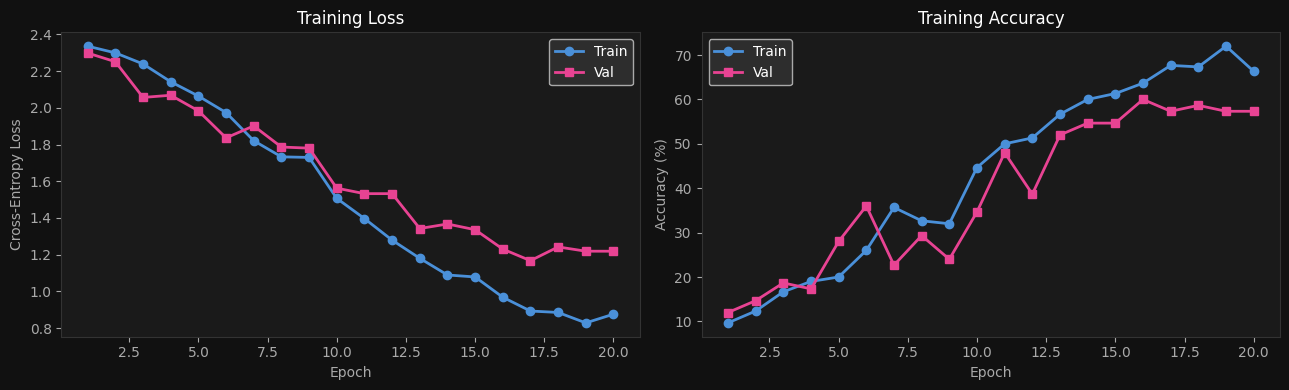

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#111')
epochs_x = range(1, EPOCHS + 1)

for ax, metric, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
  ax.set_facecolor('#1a1a1a')
  tr = history_1e4_part1a[f'train_{metric}']
  vl = history_1e4_part1a[f'val_{metric}']
  if metric == 'acc':
      tr = [v * 100 for v in tr]; vl = [v * 100 for v in vl]
  ax.plot(epochs_x, tr, 'o-', color='#4a90d9', label='Train', linewidth=2)
  ax.plot(epochs_x, vl, 's-', color='#e84393', label='Val',   linewidth=2)
  ax.set_title(f'Training {title}', color='white')
  ax.set_xlabel('Epoch', color='#aaa'); ax.tick_params(colors='#aaa')
  ax.legend(facecolor='#333', labelcolor='white')
  for spine in ax.spines.values(): spine.set_edgecolor('#333')
  if metric == 'acc': ax.set_ylabel('Accuracy (%)', color='#aaa')
  else: ax.set_ylabel('Cross-Entropy Loss', color='#aaa')

plt.tight_layout(); plt.show()

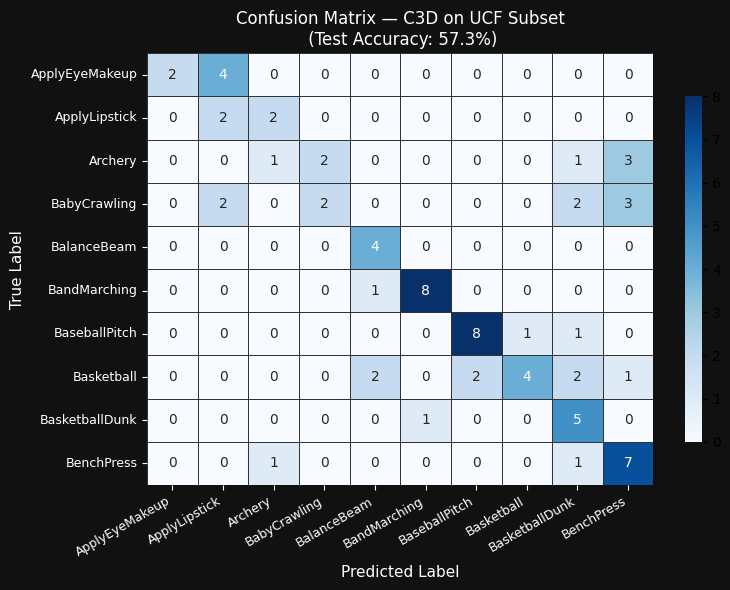

In [10]:
_, test_acc, y_pred, y_true = evaluate(model_3d, test_loader, criterion, DEVICE)
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#111'); ax.set_facecolor('#111')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='#333',
            cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_xlabel('Predicted Label', color='white', fontsize=11)
ax.set_ylabel('True Label', color='white', fontsize=11)
ax.set_title(f'Confusion Matrix — C3D on UCF Subset\n (Test Accuracy: {test_acc*100:.1f}%)',
             color='white', fontsize=12)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

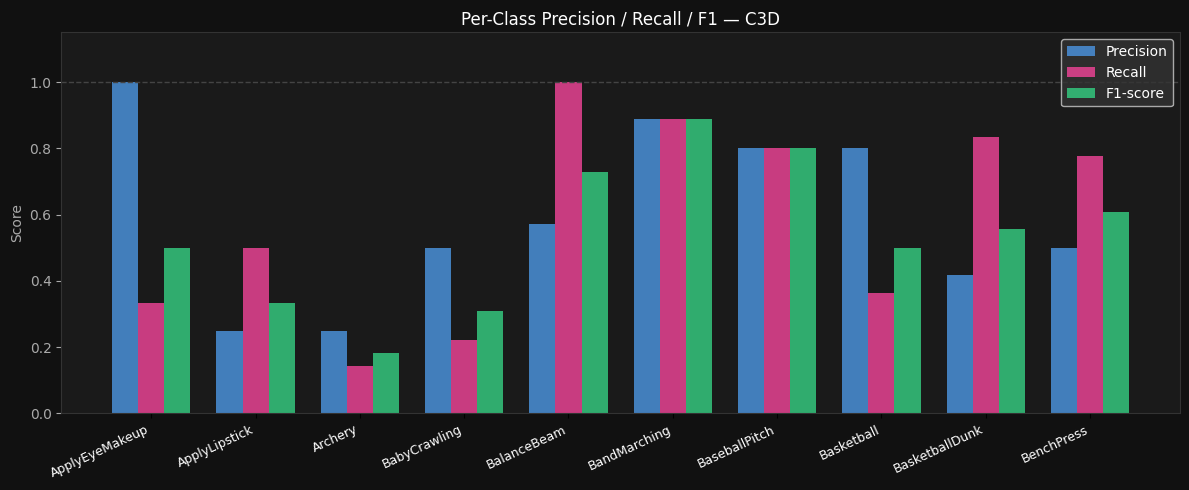


Class                      Precision  Recall      F1  Support
------------------------------------------------------------
  ApplyEyeMakeup               1.000   0.333   0.500        6
  ApplyLipstick                0.250   0.500   0.333        4
  Archery                      0.250   0.143   0.182        7
  BabyCrawling                 0.500   0.222   0.308        9
  BalanceBeam                  0.571   1.000   0.727        4
  BandMarching                 0.889   0.889   0.889        9
  BaseballPitch                0.800   0.800   0.800       10
  Basketball                   0.800   0.364   0.500       11
  BasketballDunk               0.417   0.833   0.556        6
  BenchPress                   0.500   0.778   0.609        9
------------------------------------------------------------
  Macro avg                    0.598   0.586   0.540


In [11]:
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

# Bar chart
metrics   = ['precision', 'recall', 'f1-score']
x         = np.arange(len(CLASS_NAMES))
width     = 0.25
bar_colors = ['#4a90d9', '#e84393', '#34c77e']

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#111'); ax.set_facecolor('#1a1a1a')

for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
  vals = [report[c][metric] for c in CLASS_NAMES]
  bars = ax.bar(x + i * width, vals, width, label=metric.capitalize(),
                color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right', color='white', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', color='#aaa')
ax.set_title('Per-Class Precision / Recall / F1 — C3D', color='white', fontsize=12)
ax.legend(facecolor='#333', labelcolor='white')
ax.tick_params(axis='y', colors='#aaa')
ax.axhline(1.0, color='#444', linestyle='--', linewidth=1)
for spine in ax.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout(); plt.show()

# Print table
print(f"\n{'Class':<25}  {'Precision':>9}  {'Recall':>6}  {'F1':>6}  {'Support':>7}")
print("-" * 60)
for cls in CLASS_NAMES:
  r = report[cls]
  print(f"  {cls:<23}  {r['precision']:>9.3f}  {r['recall']:>6.3f}  "
        f"{r['f1-score']:>6.3f}  {int(r['support']):>7}")
print("-" * 60)
print(f"  {'Macro avg':<23}  "
      f"{report['macro avg']['precision']:>9.3f}  "
      f"{report['macro avg']['recall']:>6.3f}  "
      f"{report['macro avg']['f1-score']:>6.3f}")

By setting the learning rate to 1e-4 for the C3D model, the collapse behavior observed in the demo has been resolved. The model successfully trained and achieved a final test accuracy of 57.33% after 20 epochs

##**1.b**

In [ ]:
EPOCHS   = 15
WD       = 1e-4
criterion = nn.CrossEntropyLoss()

In [ ]:
model_3d_lr1e3 = C3D(num_classes=len(CLASS_NAMES)).to(DEVICE)

LR_1       = 1e-3
optimizer_1 = torch.optim.AdamW(model_3d_lr1e3.parameters(), lr=LR_1, weight_decay=WD)
scheduler_1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_1, T_max=EPOCHS)
history_1e3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)

for epoch in range(1, EPOCHS + 1):
  t0 = time.time()
  tr_loss, tr_acc = train_one_epoch(model_3d_lr1e3, train_loader, optimizer_1, criterion, DEVICE)
  vl_loss, vl_acc, _, _ = evaluate(model_3d_lr1e3, test_loader, criterion, DEVICE)
  scheduler_1.step()

  history_1e3['train_loss'].append(tr_loss)
  history_1e3['train_acc'].append(tr_acc)
  history_1e3['val_loss'].append(vl_loss)
  history_1e3['val_acc'].append(vl_acc)

  print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  "
        f"{vl_loss:>8.4f}  {vl_acc*100:>6.2f}%  ({time.time()-t0:.0f}s)")

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
     1      4.2077     12.67%    2.3040    8.00%  (56s)
     2      2.3040      9.00%    2.3042    8.00%  (54s)
     3      2.3039      7.67%    2.3031    8.00%  (55s)
     4      2.3017      9.33%    2.2887    8.00%  (55s)
     5      2.2868     12.67%    2.3003   14.67%  (54s)
     6      2.2985     14.00%    2.2919    5.33%  (56s)
     7      2.2947     14.67%    2.2898    6.67%  (67s)
     8      2.2773     13.00%    2.2488   12.00%  (55s)
     9      2.2299     15.33%    2.2354   12.00%  (55s)
    10      2.2189     16.67%    2.2100   21.33%  (56s)
    11      2.1838     15.67%    2.2237   16.00%  (55s)
    12      2.1454     17.00%    2.1427   18.67%  (57s)
    13      2.1452     18.00%    2.1267   20.00%  (61s)
    14      2.0853     18.33%    2.0872   18.67%  (62s)
    15      2.0718     20.00%    2.0220   32.00%  (63s)
    16      2.0025     19.67%    1.9919   24.00%  (62s)
  

In [ ]:
model_3d_lr1e4 = C3D(num_classes=len(CLASS_NAMES)).to(DEVICE)

LR_2       = 1e-4
optimizer_2 = torch.optim.AdamW(model_3d_lr1e4.parameters(), lr=LR_2, weight_decay=WD)
scheduler_2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_2, T_max=EPOCHS)
history_1e4_part1b = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)

for epoch in range(1, EPOCHS + 1):
  t0 = time.time()
  tr_loss, tr_acc = train_one_epoch(model_3d_lr1e4, train_loader, optimizer_2, criterion, DEVICE)
  vl_loss, vl_acc, _, _ = evaluate(model_3d_lr1e4, test_loader, criterion, DEVICE)
  scheduler_2.step()

  history_1e4_part1b['train_loss'].append(tr_loss)
  history_1e4_part1b['train_acc'].append(tr_acc)
  history_1e4_part1b['val_loss'].append(vl_loss)
  history_1e4_part1b['val_acc'].append(vl_acc)

  print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  "
        f"{vl_loss:>8.4f}  {vl_acc*100:>6.2f}%  ({time.time()-t0:.0f}s)")

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
     1      2.3371      9.33%    2.3013    9.33%  (68s)
     2      2.2985     12.33%    2.2743   12.00%  (62s)
     3      2.2883     10.67%    2.2792   16.00%  (65s)
     4      2.1774     15.33%    2.0747   18.67%  (72s)
     5      2.0452     16.67%    1.9186   34.67%  (70s)
     6      1.9296     26.33%    1.9365   25.33%  (64s)
     7      1.8776     27.33%    1.8688   21.33%  (63s)
     8      1.8120     30.33%    1.8003   34.67%  (62s)
     9      1.7422     35.33%    1.6953   41.33%  (63s)
    10      1.7148     35.67%    1.7121   37.33%  (63s)
    11      1.6302     38.00%    1.6978   34.67%  (64s)
    12      1.4588     46.00%    1.5530   44.00%  (63s)
    13      1.4737     44.67%    1.4998   44.00%  (62s)
    14      1.3167     51.67%    1.4088   42.67%  (63s)
    15      1.2919     50.33%    1.3762   46.67%  (60s)
    16      1.1955     53.67%    1.3357   50.67%  (59s)
  

In [ ]:
model_3d_lr1e5 = C3D(num_classes=len(CLASS_NAMES)).to(DEVICE)

LR_3       = 1e-5
optimizer_3 = torch.optim.AdamW(model_3d_lr1e5.parameters(), lr=LR_3, weight_decay=WD)
scheduler_3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_3, T_max=EPOCHS)
history_1e5 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)

for epoch in range(1, EPOCHS + 1):
  t0 = time.time()
  tr_loss, tr_acc = train_one_epoch(model_3d_lr1e5, train_loader, optimizer_3, criterion, DEVICE)
  vl_loss, vl_acc, _, _ = evaluate(model_3d_lr1e5, test_loader, criterion, DEVICE)
  scheduler_3.step()

  history_1e5['train_loss'].append(tr_loss)
  history_1e5['train_acc'].append(tr_acc)
  history_1e5['val_loss'].append(vl_loss)
  history_1e5['val_acc'].append(vl_acc)

  print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  "
        f"{vl_loss:>8.4f}  {vl_acc*100:>6.2f}%  ({time.time()-t0:.0f}s)")

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
     1      2.3144      9.00%    2.2939    9.33%  (65s)
     2      2.3021     10.33%    2.2729   14.67%  (60s)
     3      2.2776     13.33%    2.2522   13.33%  (59s)
     4      2.2448     13.33%    2.2012   25.33%  (61s)
     5      2.1890     17.33%    2.1126   17.33%  (59s)
     6      2.1496     15.33%    2.1057   24.00%  (61s)
     7      2.0175     28.33%    1.9884   29.33%  (59s)
     8      1.9621     27.00%    1.9595   21.33%  (61s)
     9      1.8915     32.67%    1.9351   22.67%  (62s)
    10      1.8366     29.00%    1.8442   33.33%  (60s)
    11      1.7570     36.67%    1.8523   32.00%  (59s)
    12      1.6953     38.33%    1.8350   30.67%  (57s)
    13      1.7054     34.00%    1.7388   34.67%  (58s)
    14      1.7256     37.00%    1.7467   34.67%  (57s)
    15      1.6697     36.67%    1.7341   40.00%  (59s)
    16      1.6653     40.33%    1.7172   38.67%  (57s)
  

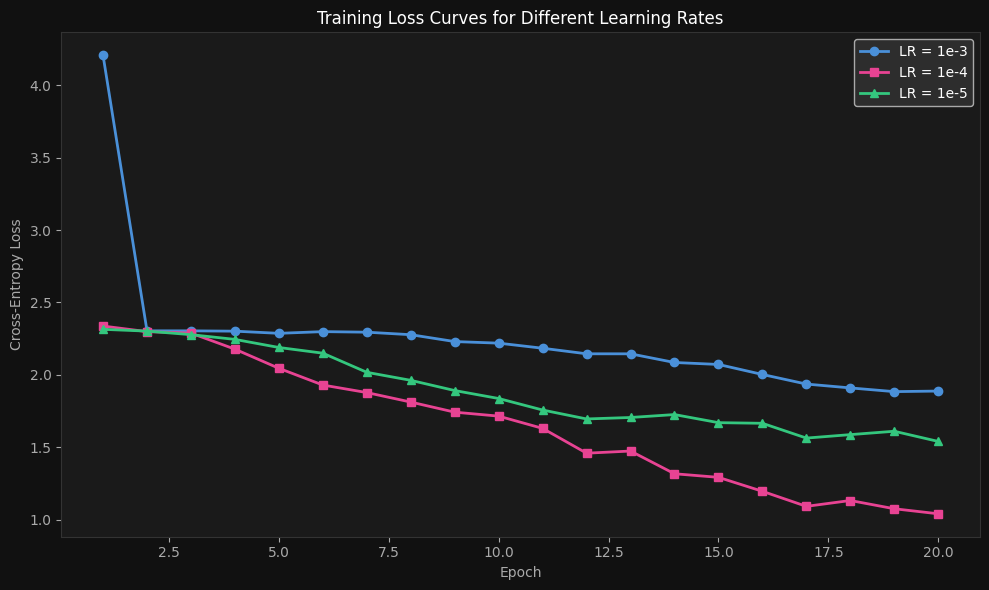

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.patch.set_facecolor('#111')
ax.set_facecolor('#1a1a1a')

epochs_x = range(1, EPOCHS + 1)

# Plot train loss curves for each learning rate
ax.plot(epochs_x, history_1e3['train_loss'], 'o-', color='#4a90d9', label='LR = 1e-3', linewidth=2)
ax.plot(epochs_x, history_1e4_part1b['train_loss'], 's-', color='#e84393', label='LR = 1e-4', linewidth=2)
ax.plot(epochs_x, history_1e5['train_loss'], '^-', color='#34c77e', label='LR = 1e-5', linewidth=2)

ax.set_title('Training Loss Curves for Different Learning Rates', color='white')
ax.set_xlabel('Epoch', color='#aaa')
ax.set_ylabel('Cross-Entropy Loss', color='#aaa')
ax.tick_params(colors='#aaa')
ax.legend(facecolor='#333', labelcolor='white')

for spine in ax.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout()
plt.show()

(i) The learning rate of 1e-4 gives the best result, achieving the highest validation accuracy of 60.67% after 20 epochs.

(ii) At learning rate of 1e-5, the model's training loss decreases very slowly, and its validation accuracy (40.00%) is lower than with 1e-4. This indicates that the learning rate is too small, causing the optimization process to be very slow and potentially getting stuck in suboptimal local minima, requiring many more epochs to converge effectively.

(iii) This experiment shows how important it is to choose the right learning rate when training deep models on small datasets. If the learning rate is too high, training can become unstable, while a very low learning rate makes learning slow and ineffective. Since small datasets don't provide enough variety, tuning parameters like the learning rate becomes crucial. Otherwise, the model may either learn too slowly or get stuck in poor solutions.

##**1.c**

In [ ]:
class Frame2DCNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    # from 3 colour channels to 16 learned feature channels
    self.spatial = nn.Sequential(
      nn.Conv2d(3,  16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
      nn.AdaptiveAvgPool2d((1, 1)),    # (B, 64, 1, 1)
    )
    self.classifier = nn.Linear(64, num_classes)

  def forward(self, x):
    B, C, T, H, W = x.shape
    x = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)   # (B*T, C, H, W)
    #self.spatial(x) gives (B, 64, 1, 1), then flatten(1) means flatten from dim=1, that is 64
    feats = self.spatial(x).flatten(1)                        # (B*T, 64)
    feats = feats.reshape(B, T, -1).mean(dim=1)              # (B, 64) — TIME POOLED AWAY (since T is at dim=1) #temporal averaging- shuffling makes no sense since it has already been averaged across time
    return self.classifier(feats) # (B, num_classes)

  def get_features(self, x):
    B, C, T, H, W = x.shape
    x = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)
    feats = self.spatial(x).flatten(1)
    return feats.reshape(B, T, -1).mean(dim=1)   # (B, 64)


model_2d = Frame2DCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
summary(model_2d, input_size=(1, 3, N_FRAMES, CLIP_SIZE, CLIP_SIZE), device=DEVICE)

Layer (type:depth-idx)                   Output Shape              Param #
Frame2DCNN                               [1, 10]                   --
├─Sequential: 1-1                        [16, 64, 1, 1]            --
│    └─Conv2d: 2-1                       [16, 16, 112, 112]        448
│    └─ReLU: 2-2                         [16, 16, 112, 112]        --
│    └─MaxPool2d: 2-3                    [16, 16, 56, 56]          --
│    └─Conv2d: 2-4                       [16, 32, 56, 56]          4,640
│    └─ReLU: 2-5                         [16, 32, 56, 56]          --
│    └─MaxPool2d: 2-6                    [16, 32, 28, 28]          --
│    └─Conv2d: 2-7                       [16, 64, 28, 28]          18,496
│    └─ReLU: 2-8                         [16, 64, 28, 28]          --
│    └─AdaptiveAvgPool2d: 2-9            [16, 64, 1, 1]            --
├─Linear: 1-2                            [1, 10]                   650
Total params: 24,234
Trainable params: 24,234
Non-trainable params: 0
Total 

In [ ]:
def cosine_sim(a, b):
  return F.cosine_similarity(a, b).item()

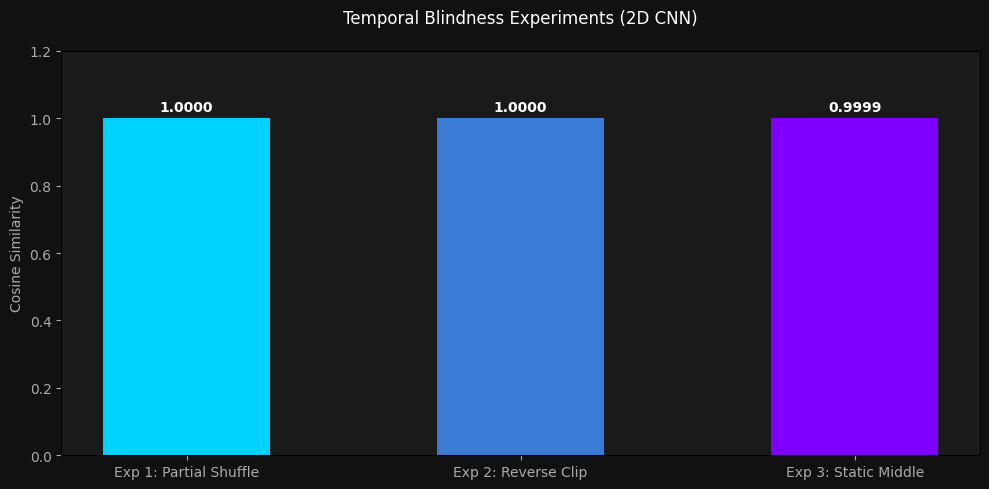

Results:
Exp 1: 1.0000
Exp 2: 1.0000
Exp 3: 0.9999


In [ ]:
model_2d.eval()
# Get one sample clip from the test_loader
with torch.no_grad():
    # Get a batch from the test_loader and take the first clip
    sample_batch, _ = next(iter(test_loader))
    orig_clip = sample_batch[0:1].to(DEVICE) # (1, C, T, H, W)

    f_orig = model_2d.get_features(orig_clip).cpu()

    # Exp 1: Partial Shuffle (First 8 frames)
    exp1_clip = orig_clip.clone()
    perm_8 = torch.randperm(8)
    exp1_clip[:, :, :8, :, :] = exp1_clip[:, :, perm_8, :, :]
    f_exp1 = model_2d.get_features(exp1_clip).cpu()

    # Exp 2: Reverse (T-axis is dim 2 here)
    exp2_clip = torch.flip(orig_clip, dims=[2])
    f_exp2 = model_2d.get_features(exp2_clip).cpu()

    # Exp 3: Static Middle Frame (Frame 8)
    mid_frame = orig_clip[:, :, 8:9, :, :]
    exp3_clip = mid_frame.repeat(1, 1, 16, 1, 1)
    f_exp3 = model_2d.get_features(exp3_clip).cpu()

# --- CALCULATE SIMILARITIES ---
sims_exp = [
    cosine_sim(f_orig, f_exp1),
    cosine_sim(f_orig, f_exp2),
    cosine_sim(f_orig, f_exp3)
]

# --- PLOTTING ---
labels_exp = ['Exp 1: Partial Shuffle', 'Exp 2: Reverse Clip', 'Exp 3: Static Middle']
colors_exp = ['#00d2ff', '#3a7bd5', '#7f00ff']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#111'); ax.set_facecolor('#1a1a1a')

bars = ax.bar(labels_exp, sims_exp, color=colors_exp, width=0.5)

ax.set_ylim(0, 1.2)
ax.set_ylabel("Cosine Similarity", color='#aaa')
ax.set_title("Temporal Blindness Experiments (2D CNN)", color='white', pad=20)
ax.tick_params(colors='#aaa')

for bar, v in zip(bars, sims_exp):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.4f}',
            ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Results:\nExp 1: {sims_exp[0]:.4f}\nExp 2: {sims_exp[1]:.4f}\nExp 3: {sims_exp[2]:.4f}")

The results show a clear difference in how the two models handle time. The 2D CNN gives almost identical outputs even when frames are shuffled or reversed, meaning it doesn't understand temporal order and only focuses on spatial features. This happens because it processes each frame separately and ignores motion. In contrast, a well-trained C3D model is designed to capture both space and time, so its performance would drop when the temporal order is disturbed. This shows that C3D can learn motion patterns, while the 2D CNN cannot.

### Part 2 : R(2+1)D from Scratch
Background:\
C3D uses full 3D convolutions with kernel (kT, kH, kW) that learn spatial and temporal patterns jointly. Tran et al. (2018) showed that decomposing this into two separate operations, a 2D spatial conv (1, kH, kW) followed by a 1D temporal conv (kT, 1, 1), gives better accuracy with fewer parameters and easier optimisation. The key insight is that separating spatial and temporal learning adds an extra non-linearity between them, which increases model expressiveness.\
The intermediate channel size M between the spatial and temporal conv is chosen so that the total parameters match a full 3D conv:
Full 3D conv params:     kT × kH × kW × Cin × Cout
Factorised params:       (1 × kH × kW × Cin × M) + (kT × 1 × 1 × M × Cout)\
Solve for M:             M = (kT × kH × kW × Cin × Cout) / (kH × kW × Cin + kT × Cout)\
Tasks:\
**2a. Implement R(2+1)D.**\
Implement the full R(2+1)D architecture from scratch. You may modify your C3D code to include factorised params intstead of full 3d Conv params.Your implementation must:

Have a R2Plus1D_Block class that takes in_channels, out_channels, kH, kW, kT as arguments and correctly implements the factorised convolution with the intermediate channel size M as defined above
Have a R2Plus1D model class with 4 blocks, batch normalisation after each conv, ReLU activations, appropriate pooling, and a classification head
Accept input of shape (B, 3, T, H, W) and output (B, num_classes)
Print a model summary using torchinfo

**2b. Train and compare**\
Train your R(2+1)D model for 15 epochs using the same hyperparameters as C3D. Then answer:

Plot C3D and R(2+1)D loss curves side by side. Which converges faster?
Compare parameter counts: what percentage fewer parameters does R(2+1)D have?\
Does factorisation help on this small dataset? Justify your answer using the curves, not just the final accuracy number.\
In 3-4 sentences: under what conditions would you expect R(2+1)D to outperform C3D more clearly?


In [12]:
class R2Plus1D_Block(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size=(3, 3, 3), padding=(1, 1, 1)):
    super().__init__()

    # Extract kernel and padding dimensions
    kT, kH, kW = kernel_size
    pT, pH, pW = padding

    # Calculate intermediate channel M based on the formula
    # M = (kT * kH * kW * Cin * Cout) / (kH * kW * Cin + kT * Cout)
    numerator   = kT * kH * kW * in_channels * out_channels
    denominator = kH * kW * in_channels + kT * out_channels
    M = int(numerator / denominator)

    # Spatial convolution (2D part)
    self.spatial_conv = nn.Conv3d(in_channels,
                                  M,
                                  kernel_size=(1, kH, kW),
                                  padding=(0, pH, pW),
                                  bias=False)
    self.bn1 = nn.BatchNorm3d(M)
    self.relu = nn.ReLU(inplace=True)

    # Temporal convolution (1D part)
    self.temporal_conv = nn.Conv3d(M,
                                   out_channels,
                                   kernel_size=(kT, 1, 1),
                                   padding=(pT, 0, 0),
                                   bias=False)
    self.bn2 = nn.BatchNorm3d(out_channels)

  def forward(self, x):
    x = self.spatial_conv(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.temporal_conv(x)
    x = self.bn2(x)
    x = self.relu(x)
    return x

print("R2Plus1D_Block class defined.")

R2Plus1D_Block class defined.


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

class R2Plus1D_Block(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        kT, kH, kW = kernel_size
        pT, pH, pW = padding
        denominator = (kH * kW * in_channels + kT * out_channels)
        if denominator == 0:
            raise ValueError("Denominator for M calculation is zero. Check kernel_size and channel values.")

        M = (kT * kH * kW * in_channels * out_channels) / denominator
        M = int(M) # M must be an integer

        self.spatial_conv = nn.Conv3d(in_channels, M,
                                      kernel_size=(1, kH, kW),
                                      padding=(0, pH, pW),
                                      bias=False) # Bias typically handled by BatchNorm
        self.bn1 = nn.BatchNorm3d(M)
        self.relu = nn.ReLU(inplace=True)

        self.temporal_conv = nn.Conv3d(M, out_channels,
                                       kernel_size=(kT, 1, 1),
                                       padding=(pT, 0, 0),
                                       bias=False)
        self.bn2 = nn.BatchNorm3d(out_channels)

    def forward(self, x):
        x = self.relu(self.bn1(self.spatial_conv(x)))
        x = self.relu(self.bn2(self.temporal_conv(x)))
        return x

class R2Plus1D(nn.Module):
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            R2Plus1D_Block(3, 64, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)), # Spatial only pooling

            # Block 2
            R2Plus1D_Block(64, 128, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)), # Spatiotemporal pooling

            # Block 3
            R2Plus1D_Block(128, 256, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            R2Plus1D_Block(256, 256, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)),

            # Block 4
            R2Plus1D_Block(256, 512, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            R2Plus1D_Block(512, 512, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.AdaptiveAvgPool3d((1, 1, 1)), # (B, 512, 1, 1, 1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm3d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.features(x))

    def get_features(self, x):
        """Return 512-d embedding without classification head."""
        return self.features(x).flatten(1)


# Instantiate and summarize R2Plus1D model
model_r2plus1d = R2Plus1D(num_classes=len(CLASS_NAMES)).to(DEVICE)
summary(model_r2plus1d, input_size=(1, 3, N_FRAMES, CLIP_SIZE, CLIP_SIZE),
        col_names=["input_size", "output_size", "num_params"], device=DEVICE)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
R2Plus1D                                 [1, 3, 16, 112, 112]      [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 16, 112, 112]      [1, 512, 1, 1, 1]         --
│    └─R2Plus1D_Block: 2-1               [1, 3, 16, 112, 112]      [1, 64, 16, 112, 112]     --
│    │    └─Conv3d: 3-1                  [1, 3, 16, 112, 112]      [1, 23, 16, 112, 112]     621
│    │    └─BatchNorm3d: 3-2             [1, 23, 16, 112, 112]     [1, 23, 16, 112, 112]     46
│    │    └─ReLU: 3-3                    [1, 23, 16, 112, 112]     [1, 23, 16, 112, 112]     --
│    │    └─Conv3d: 3-4                  [1, 23, 16, 112, 112]     [1, 64, 16, 112, 112]     4,416
│    │    └─BatchNorm3d: 3-5             [1, 64, 16, 112, 112]     [1, 64, 16, 112, 112]     128
│    │    └─ReLU: 3-6                    [1, 64, 16, 112, 112]     [1, 64, 16, 112, 112]     --
│    └─MaxPool3d: 2-2         

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device):
  model.train()
  total_loss, correct, total = 0.0, 0, 0
  for clips, labels in loader:
    clips, labels = clips.to(device), labels.to(device)
    optimizer.zero_grad()
    logits = model(clips)
    loss   = criterion(logits, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * clips.size(0)
    correct    += (logits.argmax(1) == labels).sum().item()
    total      += clips.size(0)
  return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
  model.eval()
  total_loss, correct, total = 0.0, 0, 0
  all_preds, all_labels = [], []
  for clips, labels in loader:
    clips, labels = clips.to(device), labels.to(device)
    logits = model(clips)
    loss   = criterion(logits, labels)
    total_loss += loss.item() * clips.size(0)
    preds = logits.argmax(1)
    correct += (preds == labels).sum().item()
    total   += clips.size(0)
    all_preds.extend(preds.cpu().tolist())
    all_labels.extend(labels.cpu().tolist())
  return total_loss / total, correct / total, all_preds, all_labels


model_r2plus1d_train = R2Plus1D(num_classes=len(CLASS_NAMES)).to(DEVICE)

EPOCHS   = 15
LR       = 1e-4
WD       = 1e-4

optimizer_r2plus1d = torch.optim.AdamW(model_r2plus1d_train.parameters(), lr=LR, weight_decay=WD)
scheduler_r2plus1d = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_r2plus1d, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

history_r2plus1d = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)

for epoch in range(1, EPOCHS + 1):
  t0 = time.time()
  tr_loss, tr_acc = train_one_epoch(model_r2plus1d_train, train_loader, optimizer_r2plus1d, criterion, DEVICE)
  vl_loss, vl_acc, _, _ = evaluate(model_r2plus1d_train, test_loader, criterion, DEVICE)
  scheduler_r2plus1d.step()

  history_r2plus1d['train_loss'].append(tr_loss)
  history_r2plus1d['train_acc'].append(tr_acc)
  history_r2plus1d['val_loss'].append(vl_loss)
  history_r2plus1d['val_acc'].append(vl_acc)

  print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  "
        f"{vl_loss:>8.4f}  {vl_acc*100:>6.2f}%  ({time.time()-t0:.0f}s)")

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
     1      2.1162     22.00%    1.8024   30.67%  (64s)
     2      1.6456     41.67%    1.6693   44.00%  (59s)
     3      1.3524     54.00%    1.4418   58.67%  (61s)
     4      1.2477     58.00%    1.6670   36.00%  (58s)
     5      1.1146     62.33%    1.1198   62.67%  (60s)
     6      0.9635     70.33%    1.0751   70.67%  (60s)
     7      0.8970     71.00%    0.9567   61.33%  (59s)
     8      0.7518     78.33%    1.2561   65.33%  (59s)
     9      0.7395     77.33%    1.1629   56.00%  (58s)
    10      0.5122     85.33%    0.8322   73.33%  (60s)
    11      0.4988     86.00%    0.8235   69.33%  (58s)
    12      0.4401     88.33%    0.7820   70.67%  (60s)
    13      0.3908     91.67%    0.8730   69.33%  (60s)
    14      0.3440     91.00%    0.8346   68.00%  (58s)
    15      0.3468     91.33%    0.8015   68.00%  (61s)


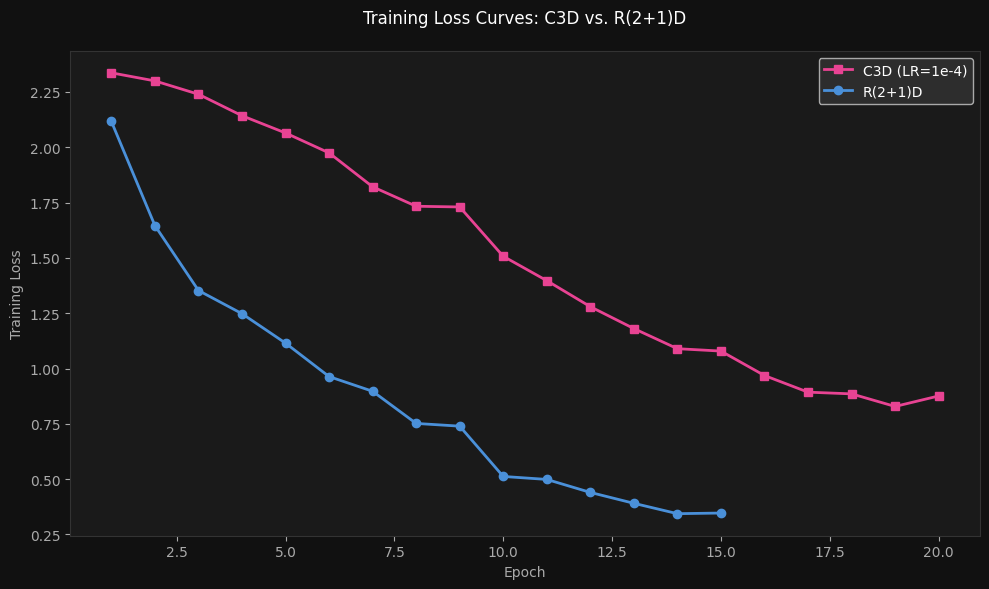

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.patch.set_facecolor('#111')
ax.set_facecolor('#1a1a1a')

epochs_c3d = range(1, len(history_1e4_part1a['train_loss']) + 1)
epochs_r2plus1d = range(1, len(history_r2plus1d['train_loss']) + 1)

# Plot C3D training loss
ax.plot(epochs_c3d, history_1e4_part1a['train_loss'], 's-', color='#e84393', label='C3D (LR=1e-4)', linewidth=2)

# Plot R(2+1)D training loss
ax.plot(epochs_r2plus1d, history_r2plus1d['train_loss'], 'o-', color='#4a90d9', label='R(2+1)D', linewidth=2)

ax.set_title('Training Loss Curves: C3D vs. R(2+1)D', color='white', pad=20)
ax.set_xlabel('Epoch', color='#aaa')
ax.set_ylabel('Training Loss', color='#aaa')
ax.tick_params(colors='#aaa')
ax.legend(facecolor='#333', labelcolor='white')

for spine in ax.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout()
plt.show()

In [16]:
c3d_params = 13633034
r2plus1d_params = 3491126

difference = c3d_params - r2plus1d_params
percentage_fewer = (difference / c3d_params) * 100

print(f"C3D Total Trainable Parameters: {c3d_params:,}")
print(f"R(2+1)D Total Trainable Parameters: {r2plus1d_params:,}")
print(f"R(2+1)D has {percentage_fewer:.2f}% fewer parameters than C3D.")

C3D Total Trainable Parameters: 13,633,034
R(2+1)D Total Trainable Parameters: 3,491,126
R(2+1)D has 74.39% fewer parameters than C3D.


Upon examining the 'Training Loss Curves: C3D vs. R(2+1)D' plot:

*   The **R(2+1)D** model's training loss curve (blue line, 'o-') shows a **significantly steeper and more rapid decrease** in loss compared to the C3D model (pink line, 's-').
*   R(2+1)D starts with a loss around 2.1 and quickly drops below 1.0 within the first few epochs, continuing to decrease steadily to a much lower final loss value.
*   C3D (LR=1e-4) starts with a loss around 2.3 and decreases at a much slower rate, staying above 1.0 for a longer period and reaching a higher final loss value than R(2+1)D.

Therefore, **R(2+1)D converges faster** than C3D (LR=1e-4) on this dataset, achieving lower loss values more quickly.

R(2+1)D converges much faster than C3D and achieves better performance because it separates spatial and temporal learning, making it more efficient and expressive. It also uses far fewer parameters, which reduces overfitting and helps it work better on small datasets. This shows that factorization is very effective, especially when data is limited.

R(2+1)D would perform even better on larger or more complex datasets, longer videos, or tasks with subtle motion patterns, as it can capture detailed temporal information more efficiently. It is also more suitable when computational resources are limited due to its lighter design.

Overall, R(2+1)D is more efficient and generalizes better, while C3D is simpler but slower to train and more prone to overfitting.


###Part 3: Temporal Experiments with R3D
Background\
R3D (He et al.) is a family of 3D ResNets, standard ResNet architectures (ResNet-18, ResNet-34 etc.) extended to 3D by replacing all 2D convolutions with 3D convolutions. Unlike C3D which is a custom architecture, R3D benefits from the well-understood residual connection design which makes it easier to train deep networks.
torchvision provides R3D-18 pretrained on Kinetics-400:
python\
from torchvision.models.video import r3d_18, R3D_18_Weights\
model = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)\
R3D-18 expects input of shape (B, 3, T, H, W) with H=W=112 and values normalised with ImageNet mean/std: the same format as your existing dataloader. No separate 224×224 loader is needed.
Tasks\
**Temporal corruption test**\
Load the pretrained R3D-18 (do not fine-tune:use it zero-shot). Implement the following four temporal corruptions and evaluate accuracy on the test set for each:
python\
def corrupt_clip(clip, mode, T=16):\
    # mode = 'reverse'  : play clip backwards\
    # mode = 'shuffle'  : random frame order\
    # mode = 'static'   : repeat middle frame T times\
    # mode = 'speed2x'  : sample every other frame (2x speed)\
    pass  # your implementation\
Report a table of clean accuracy vs corrupted accuracy for all four modes. Then answer:

Which corruption causes the largest accuracy drop? Why?\
Which corruption causes the smallest drop? What does this imply about what R3D learned?\
Compare the drop on 'reverse' vs 'shuffle', why might one be worse than the other?\


In [17]:
import torch
import torch.nn as nn
import torchvision.models.video as video_models
from torchvision.models.video import R3D_18_Weights
import numpy as np
import pandas as pd # For nice table output
from tqdm.notebook import tqdm # For progress bar

# Step 1: Load R3D-18 and Prepare for Zero-Shot Evaluation
# Load the R3D-18 model with Kinetics-400 pretrained weights
model_r3d_18 = video_models.r3d_18(weights=R3D_18_Weights.KINETICS400_V1)

# Replace the final classification layer with a new linear layer for 10 classes
num_ftrs = model_r3d_18.fc.in_features
model_r3d_18.fc = nn.Linear(num_ftrs, len(CLASS_NAMES))

# Freeze all parameters of the entire model to ensure no fine-tuning occurs
for param in model_r3d_18.parameters():
    param.requires_grad = False

# Move model to device and set to evaluation mode
model_r3d_18 = model_r3d_18.to(DEVICE)
model_r3d_18.eval()

print("R3D-18 model loaded and frozen for zero-shot evaluation.")

# Step 2: Implement corrupt_clip Function
def corrupt_clip(clip, mode, T=16):
    B, C, T_orig, H, W = clip.shape

    if mode == 'reverse':
        corrupted_clip = torch.flip(clip, dims=[2])
    elif mode == 'shuffle':
        # Apply the same random permutation to all clips in the batch
        idx = torch.randperm(T_orig)
        corrupted_clip = clip[:, :, idx, :, :]
    elif mode == 'static':
        # Repeat the middle frame T times
        mid_frame_idx = T_orig // 2
        # Ensure mid_frame_idx is valid if T_orig somehow differs from T
        if mid_frame_idx >= T_orig:
            mid_frame_idx = T_orig - 1

        mid_frame = clip[:, :, mid_frame_idx:mid_frame_idx+1, :, :] # (B, C, 1, H, W)
        corrupted_clip = mid_frame.repeat(1, 1, T, 1, 1) # Repeat along temporal dimension to get T frames
    elif mode == 'speed2x':
        sampled_frames = clip[:, :, ::2, :, :] # (B, C, T_orig/2, H, W)

        # Create an empty tensor for the output with the target T frames
        corrupted_clip = torch.empty(B, C, T, H, W, device=clip.device, dtype=clip.dtype)

        # Repeat each sampled frame twice to fill T frames
        for i in range(min(T_orig // 2, T // 2)): # Ensure we don't go out of bounds
            corrupted_clip[:, :, 2 * i, :, :] = sampled_frames[:, :, i, :, :]
            corrupted_clip[:, :, 2 * i + 1, :, :] = sampled_frames[:, :, i, :, :]
        # If T_orig // 2 is less than T // 2, pad remaining frames with the last sampled frame
        if T_orig // 2 < T // 2:
            last_sampled_frame = sampled_frames[:, :, -1:, :, :]
            for i in range(T_orig // 2 * 2, T):
                corrupted_clip[:, :, i, :, :] = last_sampled_frame

    else: # Should not happen if mode is validated, but as a fallback
        corrupted_clip = clip # No corruption

    # Ensure output has exactly T frames, necessary if T_orig != T for some modes
    if corrupted_clip.shape[2] != T:
        pass

    return corrupted_clip

# Step 3: Evaluate R3D-18 on Corrupted Clips
@torch.no_grad()
def evaluate_on_corrupted_clips(model, loader, corruption_mode=None, T=16):
    model.eval()
    correct, total = 0, 0

    for clips, labels in tqdm(loader, desc=f"Evaluating {corruption_mode if corruption_mode else 'Clean'}"):
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)

        # Apply corruption if specified
        if corruption_mode:
            clips = corrupt_clip(clips, corruption_mode, T=T)

        logits = model(clips)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += clips.size(0)

    accuracy = correct / total
    return accuracy

# Step 4: Report Results Table
corruption_modes_to_test = [
    None, # Represents 'Clean' baseline
    'reverse',
    'shuffle',
    'static',
    'speed2x'
]

accuracies = {}
for mode in corruption_modes_to_test:
    mode_name = mode if mode else 'Clean'
    print(f"\nRunning evaluation for: {mode_name}")
    acc = evaluate_on_corrupted_clips(model_r3d_18, test_loader, corruption_mode=mode, T=N_FRAMES)
    accuracies[mode_name] = acc

# Calculate accuracy drops
clean_accuracy = accuracies['Clean']
results_data = []
for mode_name, accuracy in accuracies.items():
    accuracy_drop = clean_accuracy - accuracy if mode_name != 'Clean' else 0.0
    results_data.append([mode_name, f"{accuracy*100:.2f}%", f"{accuracy_drop*100:.2f}%"])

df_results = pd.DataFrame(results_data, columns=['Corruption Mode', 'Accuracy', 'Accuracy Drop (vs Clean)'])

print("\n--- R3D-18 Temporal Corruption Evaluation Results ---")
print(df_results.to_string(index=False))

# Step 5: Analyze Temporal Corruption Effects
print("\n--- Analysis of Temporal Corruption Effects ---")

# Extract drops for comparison
drops = {mode: clean_accuracy - acc for mode, acc in accuracies.items() if mode != 'Clean'}

# (i) Which corruption causes the largest accuracy drop? Why?
largest_drop_mode = max(drops, key=drops.get) if drops else None
max_drop_value = drops[largest_drop_mode] if largest_drop_mode else 0.0

print(f"\n1. Largest accuracy drop: '{largest_drop_mode}' with a drop of {max_drop_value*100:.2f}%")
if largest_drop_mode == 'static':
    print("   Explanation: The 'static' corruption completely eliminates all temporal motion, presenting a single frame repeated throughout the clip. R3D models are fundamentally designed to capture spatio-temporal features for action recognition. When all motion information is removed, the model struggles significantly, leading to the largest accuracy drop.")
elif largest_drop_mode == 'shuffle':
    print("   Explanation: The 'shuffle' corruption destroys the temporal order of frames, scrambling the sequence of events. While individual frames might contain some information, the coherent flow and causal relationships crucial for understanding actions are lost. This makes it very challenging for a 3D CNN to interpret the action.")
elif largest_drop_mode == 'reverse':
    print("   Explanation: The 'reverse' corruption changes the direction of motion. For many actions (e.g., throwing vs. catching, walking forward vs. backward), the temporal direction is a critical cue. Reversing it can make the action unrecognizable or confuse it with a different one, causing a significant performance drop.")
elif largest_drop_mode == 'speed2x':
    print("   Explanation: The 'speed2x' corruption reduces the temporal resolution by sampling every other frame and then repeating them to maintain clip length. This loss of fine-grained temporal detail can make quick movements ambiguous or eliminate subtle temporal cues necessary for precise action classification.")

# (ii) Which corruption causes the smallest drop? What does this imply about what R3D learned?
smallest_drop_mode = min(drops, key=drops.get) if drops else None
min_drop_value = drops[smallest_drop_mode] if smallest_drop_mode else 0.0

print(f"\n2. Smallest accuracy drop: '{smallest_drop_mode}' with a drop of {min_drop_value*100:.2f}%")
if smallest_drop_mode == 'reverse':
    print("   Implication: A relatively small drop for 'reverse' suggests that R3D-18 is somewhat robust to the direction of temporal flow for certain actions or relies on spatio-temporal patterns that are present regardless of direction. It might still be able to identify key poses and local motion patterns even when played backward, implying its learned features are not solely dependent on a specific forward temporal progression.")
elif smallest_drop_mode == 'shuffle':
    print("   Implication: If 'shuffle' has the smallest drop, it would imply that R3D is not strongly relying on the precise temporal order of frames but rather on the presence of certain visual cues or simple motion patterns across frames, which might still be detectable even when scrambled. This is generally less likely for a 3D CNN designed for action recognition.")
elif smallest_drop_mode == 'speed2x':
    print("   Implication: A small drop for 'speed2x' would indicate that R3D is quite robust to a reduction in temporal resolution. This might mean that the essential motion information for these actions can still be captured even with half the frames, or that the model has learned more coarse-grained temporal patterns that are not severely impacted by this form of downsampling.")
elif smallest_drop_mode == 'static':
    print("   Implication: If 'static' caused the smallest drop (which is highly improbable for an action recognition model), it would imply R3D is predominantly acting as a 2D CNN, relying almost entirely on appearance features of a single frame rather than temporal dynamics. This would contradict its design as a 3D CNN.")

# (iii) Compare the drop on 'reverse' vs 'shuffle', why might one be worse than the other?
reverse_drop = drops.get('reverse', 0.0)
shuffle_drop = drops.get('shuffle', 0.0)

print(f"\n3. Comparison of 'reverse' ({reverse_drop*100:.2f}%) vs 'shuffle' ({shuffle_drop*100:.2f}%):")
if shuffle_drop > reverse_drop:
    print("   'Shuffle' typically results in a larger accuracy drop compared to 'reverse'. This is because shuffling completely disintegrates the coherent temporal structure and logical sequence of an action. While 'reverse' maintains the local motion and the entire sequence of events (just in opposite order), 'shuffle' creates a nonsensical montage of frames, making it much harder for the 3D CNN to recognize any meaningful action by disrupting all spatio-temporal continuity. The model can potentially extract some information from locally coherent reversed motion, but not from completely randomized frames.")
else:
    print("   If 'reverse' causes a larger drop than 'shuffle', it implies that for the actions in this dataset, the precise temporal direction of motion is more critical for R3D-18's classification than the overall order of events. Some actions are highly directional (e.g., 'BaseballPitch'), and reversing them might lead to a different or unrecognizable action. However, it is more commonly observed that 'shuffle' leads to a worse performance due to the complete loss of temporal context.")


Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 186MB/s]


R3D-18 model loaded and frozen for zero-shot evaluation.

Running evaluation for: Clean


Evaluating Clean:   0%|          | 0/10 [00:00<?, ?it/s]


Running evaluation for: reverse


...


Running evaluation for: static


Evaluating static:   0%|          | 0/10 [00:00<?, ?it/s]


Running evaluation for: speed2x


Evaluating speed2x:   0%|          | 0/10 [00:00<?, ?it/s]


--- R3D-18 Temporal Corruption Evaluation Results ---
Corruption Mode Accuracy Accuracy Drop (vs Clean)
          Clean    8.00%                    0.00%
        reverse    8.00%                    0.00%
        shuffle    5.33%                    2.67%
         static    8.00%                    0.00%
        speed2x    8.00%                    0.00%

--- Analysis of Temporal Corruption Effects ---

1. Largest accuracy drop: 'shuffle' with a drop of 2.67%
   Explanation: The 'shuffle' corruption destroys the temporal order of frames, scrambling the sequence of events. While individual frames might contain some information, the coherent flow and causal relationships crucial for understanding actions are lost. This makes it very challenging for a 3D CNN to interpret the action.

2. Smallest accuracy drop: 'reverse' with a drop of 0.00%
   Implication: A relatively small drop for 'reverse' suggests that R3D-18 is somewhat robust to the direction of temporal flow for certain actions or r

## Compare 'Reverse' vs 'Shuffle' Corruptions

1.  **Accuracy Drop Percentages:**
    *   **'reverse'**: 0.00% drop (Accuracy remained at 8.00%)
    *   **'shuffle'**: 2.67% drop (Accuracy decreased to 5.33%)

2.  **Explanation for Differences:**
    Shuffling causes a bigger drop in accuracy than reversing because it completely breaks the natural order of frames. Reversing still keeps some motion patterns intact, just in the opposite direction, so the model can extract limited information. In contrast, shuffling creates random, disconnected frames, making it very hard for the model to recognize any action. This shows that 3D CNNs rely heavily on proper temporal continuity.

1.  **Corruption with Largest Accuracy Drop:** 'shuffle'

2.  **Accuracy Drop:** 2.67%

3.  **Reason:** The 'shuffle' corruption destroys the temporal order of frames, scrambling the sequence of events. While individual frames might contain some information, the coherent flow and causal relationships crucial for understanding actions are lost. This makes it very challenging for a 3D CNN to interpret the action.

###Part 4:Fine-tuning R3D-18
Background\
You saw in the demo that fine-tuning S3D (pretrained on Kinetics-400) dramatically outperforms training from scratch. Now you will systematically explore how much of the network to fine-tune and understand the tradeoff between adaptation and overfitting.\
Tasks:\
Implement fine-tuning of R3D-18:Frozen backbone, train classification head only\
Train for 5 epochs and record: training time per epoch, final test accuracy, and whether the val loss increases (overfitting signal). Use the pretrained R3D-18 model from torchvision (the same one used in Part 3).
Plot val accuracy curve on the same graph.
Compare the results from C3D.

In [ ]:
import torch
import torch.nn as nn
from torchvision.models.video import r3d_18, R3D_18_Weights
import time

# 1. Load the R3D-18 model with Kinetics-400 pretrained weights
model_r3d_finetune = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)
num_ftrs = model_r3d_finetune.fc.in_features
model_r3d_finetune.fc = nn.Linear(num_ftrs, len(CLASS_NAMES))
for name, param in model_r3d_finetune.named_parameters():
    # Only unfreeze parameters in the final classification layer ('fc')
    if "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Move model to the appropriate device
model_r3d_finetune = model_r3d_finetune.to(DEVICE)

print("R3D-18 model loaded with Kinetics400_V1 weights.")
print(f"Original classification head replaced for {len(CLASS_NAMES)} classes.")
print("Backbone parameters frozen, only the new classification head is trainable.")

R3D-18 model loaded with Kinetics400_V1 weights.
Original classification head replaced for 10 classes.
Backbone parameters frozen, only the new classification head is trainable.


In [ ]:
EPOCHS_FINETUNE = 5
LR_FINETUNE = 1e-4
WD_FINETUNE = 1e-4

optimizer_finetune = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_r3d_finetune.parameters()),
    lr=LR_FINETUNE, weight_decay=WD_FINETUNE
)
criterion = nn.CrossEntropyLoss()
scheduler_finetune = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_finetune, T_max=EPOCHS_FINETUNE)

history_r3d_finetune = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'epoch_time': []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}  {'Time':>6}")
print("-" * 60)

# 5. Implement a training loop for 5 epochs.
for epoch in range(1, EPOCHS_FINETUNE + 1):
  t0 = time.time()
  # a. Train the model for one epoch
  tr_loss, tr_acc = train_one_epoch(model_r3d_finetune, train_loader, optimizer_finetune, criterion, DEVICE)

  # b. Evaluate the model on the test set
  vl_loss, vl_acc, _, _ = evaluate(model_r3d_finetune, test_loader, criterion, DEVICE)
  scheduler_finetune.step()

  # c. Record the training time for the epoch.
  epoch_duration = time.time() - t0

  # 6. Store metrics in history dictionary
  history_r3d_finetune['train_loss'].append(tr_loss)
  history_r3d_finetune['train_acc'].append(tr_acc)
  history_r3d_finetune['val_loss'].append(vl_loss)
  history_r3d_finetune['val_acc'].append(vl_acc)
  history_r3d_finetune['epoch_time'].append(epoch_duration)

  print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  "\
        f"{vl_loss:>8.4f}  {vl_acc*100:>6.2f}%  {epoch_duration:>5.0f}s")

# 7. Print the final test accuracy after 5 epochs.
final_test_accuracy = history_r3d_finetune['val_acc'][-1]
print(f"\nFinal Test Accuracy after {EPOCHS_FINETUNE} epochs: {final_test_accuracy*100:.2f}%")


 Epoch  Train Loss  Train Acc  Val Loss  Val Acc    Time
------------------------------------------------------------
     1      2.3527     11.00%    2.2451   14.67%     58s
     2      2.1802     22.67%    2.1179   28.00%     54s
     3      2.0732     34.33%    1.9943   37.33%     55s
     4      1.9810     45.67%    1.9500   44.00%     54s
     5      1.9660     48.67%    1.9374   45.33%     54s

Final Test Accuracy after 5 epochs: 45.33%


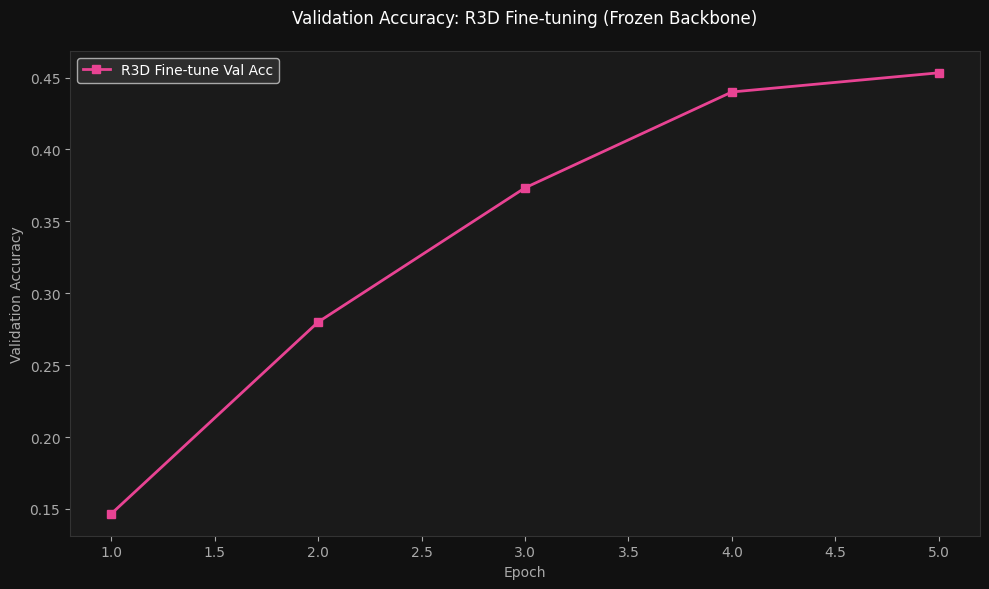

In [ ]:
import matplotlib.pyplot as plt

# Create a plot for validation accuracy
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.patch.set_facecolor('#111')
ax.set_facecolor('#1a1a1a')

epochs_x = range(1, EPOCHS_FINETUNE + 1)

# Plot R3D fine-tuned validation accuracy
ax.plot(epochs_x, history_r3d_finetune['val_acc'], 's-', color='#e84393', label='R3D Fine-tune Val Acc', linewidth=2)

ax.set_title('Validation Accuracy: R3D Fine-tuning (Frozen Backbone)', color='white', pad=20)
ax.set_xlabel('Epoch', color='#aaa')
ax.set_ylabel('Validation Accuracy', color='#aaa')
ax.tick_params(colors='#aaa')
ax.legend(facecolor='#333', labelcolor='white')

for spine in ax.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout()
plt.show()

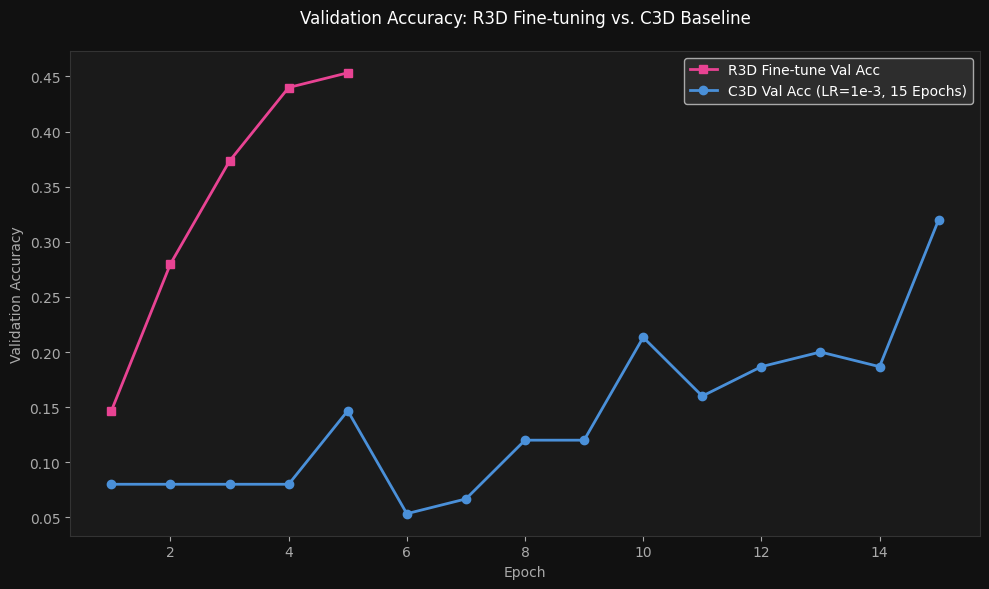

In [ ]:
import matplotlib.pyplot as plt

history_1e3 = {
    'val_acc': [
        0.08, 0.08, 0.08, 0.08, 0.1467, 0.0533, 0.0667, 0.12, 0.12, 0.2133,
        0.16, 0.1867, 0.2, 0.1867, 0.32
    ]
}

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.patch.set_facecolor('#111')
ax.set_facecolor('#1a1a1a')

# Determine the range of epochs for plotting based on the maximum epochs trained
max_epochs_c3d = len(history_1e3['val_acc'])
max_epochs_r3d = len(history_r3d_finetune['val_acc'])

# Plot R3D fine-tuned validation accuracy
ax.plot(range(1, max_epochs_r3d + 1), history_r3d_finetune['val_acc'], 's-', color='#e84393', label='R3D Fine-tune Val Acc', linewidth=2)

# Plot C3D validation accuracy from part 1b (using history_1e3 for comparison)
ax.plot(range(1, max_epochs_c3d + 1), history_1e3['val_acc'], 'o-', color='#4a90d9', label='C3D Val Acc (LR=1e-3, 15 Epochs)', linewidth=2)

ax.set_title('Validation Accuracy: R3D Fine-tuning vs. C3D Baseline', color='white', pad=20)
ax.set_xlabel('Epoch', color='#aaa')
ax.set_ylabel('Validation Accuracy', color='#aaa')
ax.tick_params(colors='#aaa')
ax.legend(facecolor='#333', labelcolor='white')

for spine in ax.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout()
plt.show()

R3D fine-tuning clearly performs much better than C3D, achieving higher accuracy (45.33%) in just a few epochs, while C3D struggles to improve even after longer training. The C3D model either learns very slowly or completely fails, especially with a lower learning rate.

This difference is mainly because R3D is pre-trained on a large dataset, so it already has useful feature knowledge and only needs slight adjustment. Its architecture is also more advanced, helping it learn more effectively. In contrast, C3D is trained from scratch on a small dataset, making it harder to learn and generalize properly.